# Real-Time Pitch Type Classification for MLB Broadcast: A Per-Pitcher Model (Kevin Gausman Proof-of-Concept)


---
embed-resources: true
echo: false
---

## **Introduction**

This report develops a *proof-of-concept*, real-time pitch-type classification system to support MLB broadcast operations for the 2025 All-Star Game. The purpose is to enable automatic, near-instant identification of pitch type immediately after a pitch is released, so that accurate pitch labels can be displayed consistently in both in-stadium graphics and television broadcasts. The goal is to demonstrate that a low-latency machine learning pipeline can reliably translate tracking measurements available in real time, such as velocity, spin rate, and pitch movement, into the corresponding pitch-type label for a single pitcher, Kevin Gausman, using a process that can be scaled to additional pitchers through a *one-model-per-pitcher* approach.

The analysis uses Statcast pitch-level tracking data accessed via Baseball Savant (pybaseball), with a time-based split reflecting operational deployment: the 2024 regular season is used for training and the first half of the 2025 regular season is reserved for testing. Each pitch includes the target label (pitch_type) and a compact feature set available immediately after release (`release_speed`, `release_spin_rate`, `pfx_x`, `pfx_z`, and batter stance `stand`). The modeling workflow employs an end-to-end *scikit-learn pipeline* that performs *missing-value imputation*, *feature scaling*, and *categorical encoding*, followed by a *K-Nearest Neighbors (KNN) classifier*. Hyperparameters are selected using cross-validated grid search *(StratifiedKFold with GridSearchCV)* to maximize accuracy while maintaining a simple and fast inference path suitable for real-time broadcast use.

## **Methods**

### Imports

In [1]:
# basic imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# modeling + tuning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

### Data

#### Source:

The original source of the data is [Statcast](https://en.wikipedia.org/wiki/Statcast). Specifically, the [pybaseball](https://pypi.org/project/pybaseball/) package was used to interface with [Statcast Search](https://baseballsavant.mlb.com/statcast_search), which is part of [Baseball Savant](https://baseballsavant.mlb.com/).

#### Data Dictionary

Each sample contains Statcast data for a single pitch thrown by Kevin Gausman in either 2024 (train data) or 2025 (test data) during an MLB regular season game.

Here, the train-test split is based on time:

- Train: 2024 MLB Season
- Test: (First Half of) 2025 MLB Season

Original and (mostly) complete documentation for Statcast data can be found in the [Statcast Search CSV Documentation](https://baseballsavant.mlb.com/csv-docs). A more detailed reference can be found in [Appendix C of Analyzing Baseball Data with R](https://beanumber.github.io/abdwr3e/C_statcast.html). Notably, [Table C.3](https://beanumber.github.io/abdwr3e/C_statcast.html#tbl-pitchTypes) maps the pitch type to a pitch name, as pitch types are shortcodes for the more descriptive pitch (type) names.

#### Variable Descriptions:

**`pitch_type`**

- `[object]` the type of the pitch

**`release_speed`**

- `[float64]` pitch velocity (miles per hour) measured shortly after leaving the pitcher's hand

**`release_spin_rate`**

- `[float64]` pitch spin rate (revolutions per minute) measured shortly after leaving the pitcher's hand

**`pfx_x`**

- `[float64]` horizontal movement (feet) of the pitch from the catcher's perspective.

**`pfx_z`**

- `[float64]` vertical movement (feet) of the pitch from the catcher's perspective.

**`stand`**

- `[object]` side of the plate batter is standing, either `L` (left) or `R` (right)

In [2]:
# load data
pitches_train = pd.read_parquet(
    "https://lab.cs307.org/pitches/data/pitches-train.parquet",
)
pitches_test = pd.read_parquet(
    "https://lab.cs307.org/pitches/data/pitches-test.parquet",
)

In [3]:
pitches_train.head(5)

,pitch_type,release_speed,release_spin_rate,pfx_x,pfx_z,stand
0,FF,97.3,2432.0,-0.80,1.61,L
1,FF,97.9,2385.0,-0.93,1.22,L
2,FF,96.6,2390.0,-0.97,1.38,L
3,FS,86.4,1492.0,-1.27,0.50,L
4,FS,88.9,1778.0,-1.14,0.68,R


#### Summary Statistics

Using the available training data, calculate some relevent summary statistics.

In [4]:
# columns in training data
print(pitches_train.shape)

(2868, 6)


In [5]:
# number of features after dropping targe variable
X_train = pitches_train.drop("pitch_type", axis=1)
X_train.shape

(2868, 5)

In [6]:
# how often each pitch type was thrown

# counts by pitch code
counts = pitches_train["pitch_type"].value_counts().sort_index()

# proportions
props = pitches_train["pitch_type"].value_counts(normalize=True).sort_index()
out = pd.DataFrame({
    "Count": counts,
    "Proportion": props
})
out

,Count,Proportion
pitch_type,,
FF,1488,0.518828
FS,959,0.334379
SI,181,0.063110
SL,240,0.083682


In [7]:
# compute the mean and standard deviation of release_speed for the four pitch types (FF, FS, SI, SL)
order = ["FF", "FS", "SI", "SL"]

vel_stats = (
    pitches_train[pitches_train["pitch_type"].isin(order)]
    .groupby("pitch_type")["release_speed"]
    .agg(["mean", "std"])
    .reindex(order)
)
vel_stats

,mean,std
pitch_type,,
FF,93.957527,1.700911
FS,85.969552,1.821758
SI,93.310497,1.739876
SL,82.747917,1.864128


In [8]:
# compute the mean and standard deviation of release_spin_rate for the four pitch types (FF, FS, SI, SL)
spin_stats = (
    pitches_train[pitches_train["pitch_type"].isin(order)]
    .groupby("pitch_type")["release_spin_rate"]
    .agg(["mean", "std"])
    .reindex(order)
)
spin_stats

,mean,std
pitch_type,,
FF,2287.098118,101.983970
FS,1764.038582,177.469770
SI,2189.022099,113.026494
SL,2239.435146,96.452687


The training data contains 2,868 pitches with four pitch types. Fastballs (FF) dominate the dataset (about 52%), followed by splitters (FS) at 33%, while sinkers (SI) and sliders (SL) are much less frequent.

In terms of release speed, FF and SI are the fastest on average (around 93 mph), FS is moderately slower (about 86 mph), and SL is the slowest (about 83 mph).

For spin rate, FF and SL show the highest average spin (around 2200–2300 rpm), SI is slightly lower, and FS has the lowest average spin. The standard deviations are relatively small, indicating consistent pitch characteristics within each type.

Overall, release speed and spin rate clearly differ across pitch types, suggesting these variables are strong predictors for classification.

#### Exploratory Visualization

In [9]:
# exploratory visualization

train = pitches_train.dropna(subset=["pitch_type","release_speed","release_spin_rate","pfx_x","pfx_z","stand"]).copy()
test  = pitches_test.dropna(subset=["pitch_type","release_speed","release_spin_rate","pfx_x","pfx_z","stand"]).copy()

##### a. Pitch-type frequency: Train (2024) vs Test (2025):

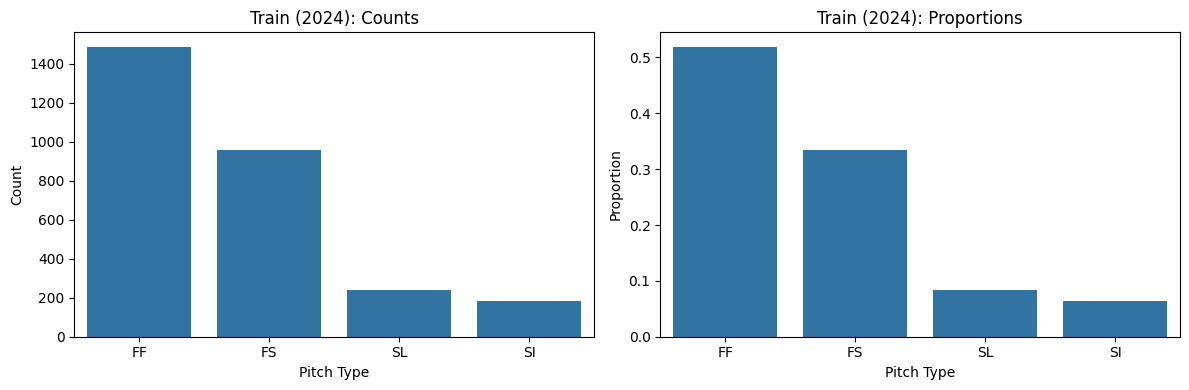

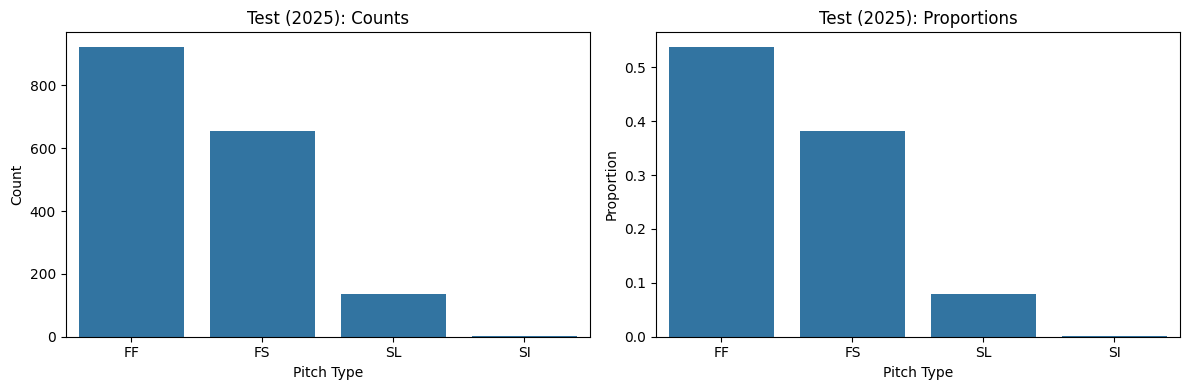

In [10]:
def plot_pitch_mix(df, title):
    counts = df["pitch_type"].value_counts().reset_index()
    counts.columns = ["pitch_type", "count"]
    counts["prop"] = counts["count"] / counts["count"].sum()

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    sns.barplot(data=counts, x="pitch_type", y="count", ax=ax[0])
    ax[0].set_title(f"{title}: Counts")
    ax[0].set_xlabel("Pitch Type")
    ax[0].set_ylabel("Count")

    sns.barplot(data=counts, x="pitch_type", y="prop", ax=ax[1])
    ax[1].set_title(f"{title}: Proportions")
    ax[1].set_xlabel("Pitch Type")
    ax[1].set_ylabel("Proportion")

    plt.tight_layout()
    plt.show()

plot_pitch_mix(train, "Train (2024)")
plot_pitch_mix(test,  "Test (2025)")



The Pitch-type frequency visualizations show that class imbalance is clear in both seasons. FF is the dominant pitch type, followed by FS, while SL and SI appear much less frequently. The overall mix is broadly consistent across years, which is good for generalization, but the test set shows an even smaller presence (near-absence) of SI. This matters because any model will have less opportunity to learn SI patterns and will likely struggle to predict SI reliably.

##### b. Scatter: release_speed vs release_spin_rate (Train 2024):

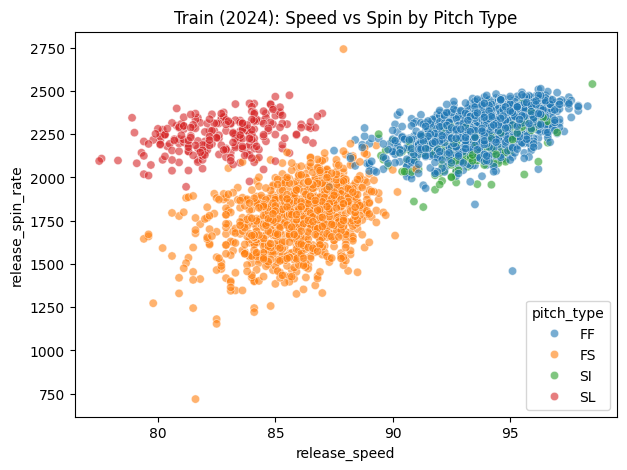

In [11]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=train, x="release_speed", y="release_spin_rate",
    hue="pitch_type", alpha=0.6
)
plt.title("Train (2024): Speed vs Spin by Pitch Type")
plt.show()

The Scatter plot above shows that FF and SI overlap in the high-velocity region, meaning speed alone will not perfectly separate them; spin and movement features (pfx_x, pfx_z) will likely be important for differentiating these.

##### c. Correlation heatmap (Train 2024):

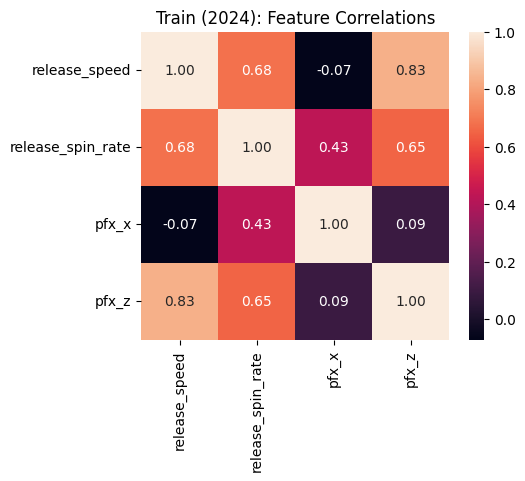

In [12]:
num_cols = ["release_speed","release_spin_rate","pfx_x","pfx_z"]
corr = train[num_cols].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, fmt=".2f", square=True)
plt.title("Train (2024): Feature Correlations")
plt.show()


The Correlations Heatmap above shows that there is moderate-to-strong correlation among some predictors:
- `release_speed` with `pfx_z` is high (0.83)
- `release_speed` with `release_spin_rate` is moderate (0.68)
- `release_spin_rate` with `pfx_z` is moderate (0.65)

### **Models**

#### Prepare Data for Machine Learning

In [13]:
# create X and y for train
X_train = pitches_train.drop("pitch_type", axis=1)
y_train = pitches_train["pitch_type"]

# create X and y for test
X_test = pitches_test.drop("pitch_type", axis=1)
y_test = pitches_test["pitch_type"]

To predict pitch type in a way that can operate in real time, the analysis treated pitch type as the outcome and used five Statcast features as inputs: *release speed*, *spin rate*, *horizontal movement (`pfx_x`)*, *vertical movement (`pfx_z`)*, and *batter stance (L/R)*. The data were partitioned using the project's time-based split: the 2024 season served as training data and the first half of the 2025 season served as the test set, mirroring the real broadcast setting where the model must generalize to future pitches.

#### Feature Preprocessing Pipeline (Imputation, Scaling, Encoding)

In [14]:
# preprocessing

num_cols = ["release_speed", "release_spin_rate", "pfx_x", "pfx_z"]
cat_cols = ["stand"]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

Before fitting the model, preprocessing was applied to make the inputs usable and comparable. Numeric features were processed by imputing missing values using the median and then standardizing each variable so that distance calculations would not be dominated by features with larger scales. The categorical variable (batter stance) was imputed using the most frequent category and converted into indicator variables via one-hot encoding, allowing it to be incorporated alongside numeric predictors. All preprocessing steps were integrated into a single pipeline so that identical transformations were applied during both training and testing, preventing inconsistencies and leakage.

#### KNN Model Training with Stratified Cross-Validation and Hyperparameter Tuning

In [15]:
# train models

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn = Pipeline([
    ("prep", preprocess),
    ("clf", KNeighborsClassifier())
])

param_grid = {
    "clf__n_neighbors": [1,3,5,7,9,10,15,20,30,40,50,60,70],
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2]
}

grid = GridSearchCV(knn, param_grid=param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
pred = best_model.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, pred))

best_model

Test accuracy: 0.9850498338870431


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

The classifier used was K-Nearest Neighbors (KNN), which assigns a pitch type based on the most similar historical pitches in feature space. Because KNN performance depends strongly on hyperparameter choices, the model was tuned using grid search with 5-fold stratified cross-validation on the 2024 training data. 

The grid search evaluated combinations of: the number of neighbors k, whether neighbors were weighted equally or weighted by distance, and the distance metric (Manhattan vs. Euclidean). The combination achieving the highest mean cross-validated accuracy was selected as the final model.

After selecting the best-performing configuration, the finalized pipeline was refit on the full 2024 training set and then evaluated on the held-out 2025 data. The model achieved 0.985 test accuracy.


In [16]:
# For Modeling Accuracy Check
from joblib import dump
dump(best_model, "pitches.joblib")

['pitches.joblib']

## Results

In [17]:
# report model metrics

# overall test accuracy
overall_test_acc = accuracy_score(y_test, pred)
print(f"Test accuracy: {overall_test_acc:.3f}")

Test accuracy: 0.985


The tuned K-Nearest Neighbors (KNN) pipeline was evaluated using the held-out 2025 test set. The model achieved a test accuracy of 0.985 on 2025 data, indicating that it correctly classified the pitch type for the vast majority of pitches when applied to a future season.

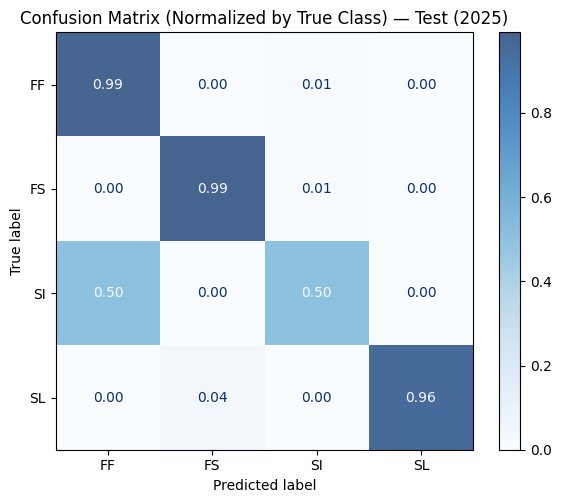

In [18]:
# summary figure

cm_norm = confusion_matrix(y_test, pred, labels=["FF", "FS", "SI", "SL"], normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=["FF", "FS", "SI", "SL"])

fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, values_format=".2f", im_kw={"cmap": "Blues", "alpha": 0.75})
ax.set_title("Confusion Matrix (Normalized by True Class) — Test (2025)")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()
plt.show()

To understand performance beyond overall accuracy, a normalized confusion matrix (by true class) was used to evaluate class-level recall. The model performed extremely well on the two most frequent pitch types, correctly identifying FF and FS at approximately 0.99 recall each. Performance on SL was also strong (0.96 recall), with a small portion of sliders predicted as splitters (0.04). The primary weakness was SI, where recall was 0.50, with the remaining sinkers most often predicted as fastballs. This pattern suggests that sinkers and four-seam fastballs are the most difficult pair for the model to separate using the current feature set and available training signal.

In [19]:
# serialize model
import joblib

joblib.dump(best_model, "best_model.joblib")
print("Saved model to best_model.joblib")

Saved model to best_model.joblib


## **Discussion**

### Production Decision

I would recommend deploy this model for the broadcast scenario. The model demonstrates strong performance on the time-based 2025 test set (accuracy = 0.985) and correctly identifies the most common pitch types (FF, FS) at very high rates.

#### Benefits to Broadcasting：

1. The model has high reliability for dominant pitch types. The FF and FS are classified with near-perfect recall, which matters most because these pitches make up the majority of the pitch mix.

2. The model can produce preedictions quickly enough for real-time overlays.

#### Limitations:

1. Weak performance on sinkers (SI): The confusion matrix shows SI recall is substantially lower (around 0.50), with many sinkers mislabeled as fastballs.

2. The SI and SL are less frequent, and the volume of data covering SI and SL in the original dataset is notably insufficient. Although SL exhibits high recall, potential issues may arise when predicting additional or novel data. Furthermore, the scarcity of SI data may also contribute to its extremely low recall rate.

#### Conclusion

This KNN model is good enough to provide meaningful broadcast value because it is highly accurate overall and extremely reliable on the most frequent pitch types.